<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/005_transfer_learning_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN treinada do zero vs MobileNetV2 pré-treinada no ImageNet

**Área:** Computer Vision   
**Tipo de problema:** Classificação multiclasse de imagens

### Pergunta de estudo

> Reutilizar representações aprendidas em um grande dataset melhora a classificação de imagens em relação a uma CNN pequena treinada do zero?

### Experimentos

1. pequena CNN treinada do zero;
2. MobileNetV2 congelada como extratora de características;
3. fine-tuning parcial da MobileNetV2.

### Observação de execução

Este notebook se beneficia bastante de **GPU no Google Colab**.

O parâmetro `FAST_MODE` permite reduzir o conjunto de treino para uma execução exploratória.  
Para o resultado a ser publicado, recomenda-se executar com `FAST_MODE = False`.


## 1. Configuração do ambiente


In [1]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    Resizing,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use False para o resultado final do repositório.
FAST_MODE = False

print("TensorFlow:", tf.__version__)
print("GPU disponível:", bool(tf.config.list_physical_devices("GPU")))


TensorFlow: 2.20.0
GPU disponível: False


## 2. Carregamento do CIFAR-10

O CIFAR-10 contém imagens coloridas `32 × 32` distribuídas em dez classes.


In [2]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Treino original:", x_train_full.shape)
print("Teste:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1968s 12us/step
Treino original: (50000, 32, 32, 3)
Teste: (10000, 32, 32, 3)


In [3]:
# Cria treino e validação estratificados.
train_idx, val_idx = train_test_split(
    np.arange(len(x_train_full)),
    test_size=5_000,
    random_state=SEED,
    stratify=y_train_full,
)

x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]

x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]

# Modo rápido: usa uma amostra estratificada do treino.
if FAST_MODE:
    selected_idx, _ = train_test_split(
        np.arange(len(x_train)),
        train_size=12_000,
        random_state=SEED,
        stratify=y_train,
    )
    x_train = x_train[selected_idx]
    y_train = y_train[selected_idx]

print("Treino:", x_train.shape)
print("Validação:", x_val.shape)
print("Teste:", x_test.shape)


Treino: (45000, 32, 32, 3)
Validação: (5000, 32, 32, 3)
Teste: (10000, 32, 32, 3)


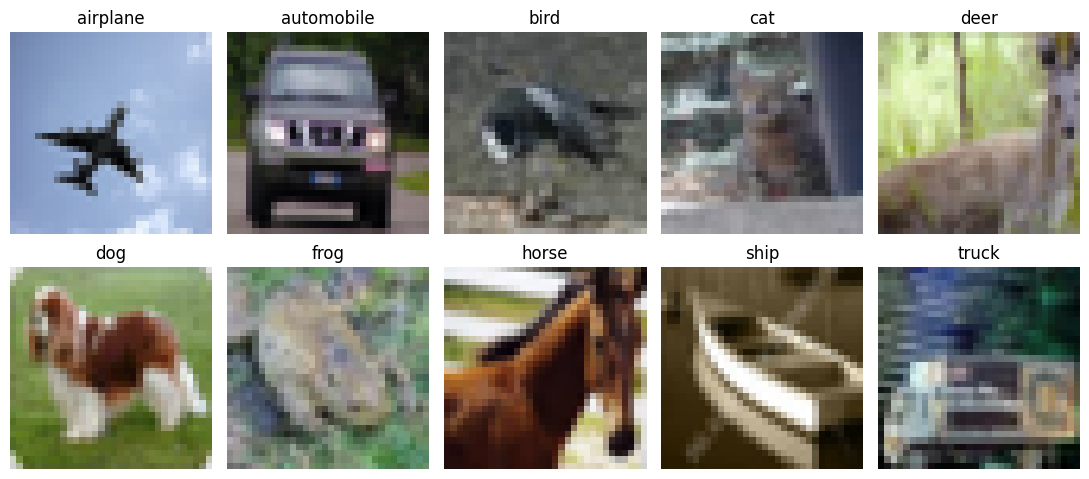

In [4]:
# Visualiza exemplos.
fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for class_id, ax in enumerate(axes.ravel()):
    idx = np.where(y_train == class_id)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[class_id])
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Baseline — pequena CNN treinada do zero

O baseline aprende todos os filtros diretamente a partir do CIFAR-10.


In [5]:
baseline_model = Sequential([
    Input(shape=(32, 32, 3)),
    tf.keras.layers.Rescaling(1.0 / 255),

    Conv2D(32, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dropout(0.30),
    Dense(10, activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

baseline_history = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15 if not FAST_MODE else 6,
    batch_size=128,
    callbacks=[baseline_early_stopping],
    verbose=1,
)


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 108s 301ms/step - accuracy: 0.2883 - loss: 1.8843 - val_accuracy: 0.3654 - val_loss: 1.6921
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.3918 - loss: 1.6375 - val_accuracy: 0.4434 - val_loss: 1.5162
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 287ms/step - accuracy: 0.4439 - loss: 1.5201 - val_accuracy: 0.4858 - val_loss: 1.4013
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.4790 - loss: 1.4381 - val_accuracy: 0.5236 - val_loss: 1.3084
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 295ms/step - accuracy: 0.5079 - loss: 1.3634 - val_accuracy: 0.5408 - val_loss: 1.2622
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 295ms/step - accuracy: 0.5261 - loss: 1.3095 - val_accuracy: 0.5740 - val_loss: 1.2081
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 292ms/step - accuracy: 0.5457 - loss: 1.2639 - val_accuracy: 0.5916 - val_loss: 1.1642
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.5638 -

## 4. Transfer Learning com MobileNetV2

A MobileNetV2 foi treinada previamente no ImageNet.

O fluxo adotado é:

1. aumentar os dados;
2. redimensionar as imagens para `96 × 96`;
3. aplicar o pré-processamento esperado pela MobileNetV2;
4. congelar o backbone;
5. treinar um novo classificador para CIFAR-10.


In [7]:
# Data augmentation aplicado somente durante treinamento.
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
], name="data_augmentation")

# Backbone pré-treinado.
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = Resizing(96, 96)(x)
x = preprocess_input(x)

# training=False mantém BatchNorm em modo de inferência.
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.30)(x)
outputs = Dense(10, activation="softmax")(x)

transfer_model = Model(inputs, outputs)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
transfer_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

transfer_history = transfer_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10 if not FAST_MODE else 5,
    batch_size=128,
    callbacks=[transfer_early_stopping],
    verbose=1,
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.6611 - loss: 1.0076 - val_accuracy: 0.8310 - val_loss: 0.4879
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.7569 - loss: 0.7058 - val_accuracy: 0.8496 - val_loss: 0.4434
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7694 - loss: 0.6677 - val_accuracy: 0.8524 - val_loss: 0.4271
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.7750 - loss: 0.6502 - val_accuracy: 0.8556 - val_loss: 0.4229
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.7771 - loss: 0.6445 - val_accuracy: 0.8538 - val_loss: 0.4247
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7779 - loss: 0.6390 - val_accuracy: 0.8596 - val_loss: 0.4107
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.7788 - loss: 0.6361 - val_accuracy: 0.8580 - val_loss: 0.4259
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.7802 - loss: 0.6333 - val_accu

## 5. Avaliação antes do fine-tuning

Antes de descongelar parte do backbone, registramos o resultado obtido apenas com extração de características.


In [9]:
transfer_frozen_probabilities = transfer_model.predict(x_test, batch_size=256, verbose=0)
transfer_frozen_predictions = transfer_frozen_probabilities.argmax(axis=1)

transfer_frozen_accuracy = accuracy_score(y_test, transfer_frozen_predictions)

print(f"Accuracy — backbone congelado: {transfer_frozen_accuracy:.4f}")


Accuracy — backbone congelado: 0.8541


## 6. Fine-tuning parcial

Após o novo classificador aprender a tarefa, as últimas camadas do backbone são liberadas.

O learning rate é reduzido para evitar atualizações agressivas nos pesos pré-treinados.


In [10]:
# Libera o backbone e congela todas as camadas exceto as 20 últimas.
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"Camadas treináveis no backbone: {trainable_count}")


Camadas treináveis no backbone: 20


In [11]:
fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

fine_tune_history = transfer_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=6 if not FAST_MODE else 3,
    batch_size=128,
    callbacks=[fine_tune_early_stopping],
    verbose=1,
)


Epoch 1/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 539s 2s/step - accuracy: 0.6955 - loss: 0.9893 - val_accuracy: 0.8412 - val_loss: 0.4771
Epoch 2/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 530s 2s/step - accuracy: 0.7571 - loss: 0.7662 - val_accuracy: 0.8562 - val_loss: 0.4473
Epoch 3/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.7739 - loss: 0.7024 - val_accuracy: 0.8630 - val_loss: 0.4245
Epoch 4/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 560s 1s/step - accuracy: 0.7883 - loss: 0.6541 - val_accuracy: 0.8664 - val_loss: 0.4103
Epoch 5/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 532s 2s/step - accuracy: 0.8005 - loss: 0.6053 - val_accuracy: 0.8700 - val_loss: 0.3982
Epoch 6/6
352/352 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.8042 - loss: 0.5812 - val_accuracy: 0.8738 - val_loss: 0.3855


## 7. Avaliação final

Os três estados são comparados:

- CNN treinada do zero;
- MobileNetV2 congelada;
- MobileNetV2 após fine-tuning.


In [12]:
baseline_probabilities = baseline_model.predict(x_test, batch_size=256, verbose=0)
baseline_predictions = baseline_probabilities.argmax(axis=1)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

fine_tuned_probabilities = transfer_model.predict(x_test, batch_size=256, verbose=0)
fine_tuned_predictions = fine_tuned_probabilities.argmax(axis=1)
fine_tuned_accuracy = accuracy_score(y_test, fine_tuned_predictions)

results = pd.DataFrame({
    "Modelo": [
        "CNN do zero",
        "MobileNetV2 congelada",
        "MobileNetV2 fine-tuned",
    ],
    "Accuracy": [
        baseline_accuracy,
        transfer_frozen_accuracy,
        fine_tuned_accuracy,
    ],
}).set_index("Modelo")

display(results.round(4))


,Accuracy
Modelo,
CNN do zero,0.6373
MobileNetV2 congelada,0.8541
MobileNetV2 fine-tuned,0.8652


In [13]:
print("MOBILENETV2 — FINE-TUNED")
print(
    classification_report(
        y_test,
        fine_tuned_predictions,
        target_names=class_names,
        digits=4,
    )
)


MOBILENETV2 — FINE-TUNED
              precision    recall  f1-score   support

    airplane     0.8897    0.8710    0.8802      1000
  automobile     0.9244    0.9540    0.9390      1000
        bird     0.9092    0.7910    0.8460      1000
         cat     0.7588    0.7360    0.7472      1000
        deer     0.8382    0.8390    0.8386      1000
         dog     0.8288    0.7940    0.8110      1000
        frog     0.7948    0.9450    0.8634      1000
       horse     0.8977    0.8690    0.8831      1000
        ship     0.9194    0.9240    0.9217      1000
       truck     0.9037    0.9290    0.9162      1000

    accuracy                         0.8652     10000
   macro avg     0.8665    0.8652    0.8646     10000
weighted avg     0.8665    0.8652    0.8646     10000



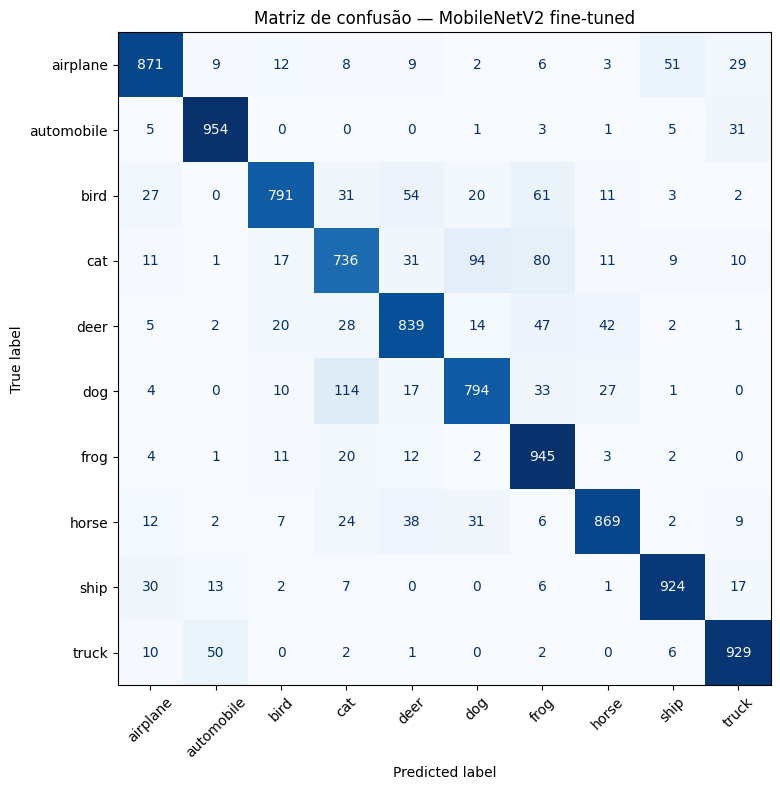

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    fine_tuned_predictions,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title("Matriz de confusão — MobileNetV2 fine-tuned")
plt.tight_layout()
plt.show()


## 8. Análise de erros


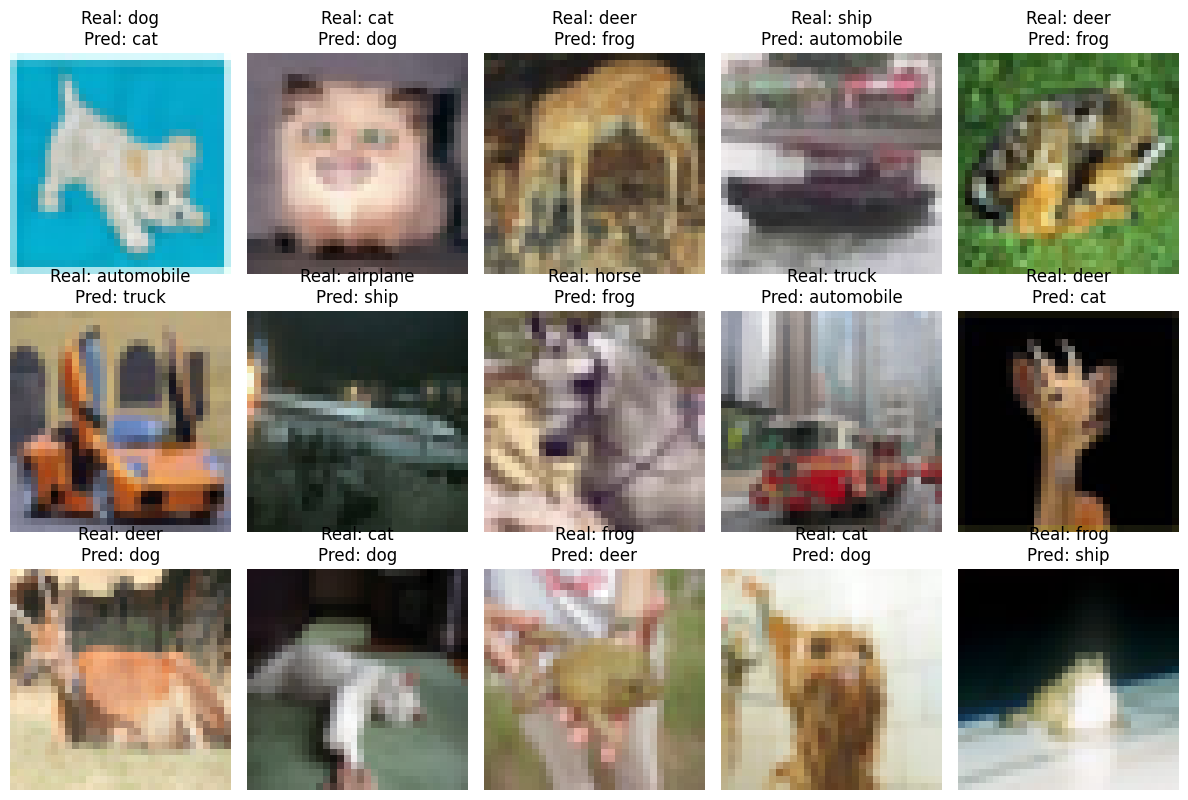

In [15]:
wrong_indices = np.where(fine_tuned_predictions != y_test)[0]

rng = np.random.default_rng(SEED)
sample_size = min(15, len(wrong_indices))
sample_indices = rng.choice(wrong_indices, size=sample_size, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for idx, ax in zip(sample_indices, axes.ravel()):
    ax.imshow(x_test[idx])
    ax.set_title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[fine_tuned_predictions[idx]]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 9. Conclusão


In [16]:
from IPython.display import Markdown, display

winner = results["Accuracy"].idxmax()
winner_accuracy = results.loc[winner, "Accuracy"]
gain_vs_baseline = (fine_tuned_accuracy - baseline_accuracy) * 100
fine_tune_gain = (fine_tuned_accuracy - transfer_frozen_accuracy) * 100

conclusion = f'''
### Síntese dos resultados

O melhor resultado desta execução foi obtido por **{winner}**, com accuracy de **{winner_accuracy:.4f}**.

Comparando especificamente:

- **CNN do zero:** {baseline_accuracy:.4f}
- **MobileNetV2 congelada:** {transfer_frozen_accuracy:.4f}
- **MobileNetV2 fine-tuned:** {fine_tuned_accuracy:.4f}

O fine-tuning alterou a accuracy em **{fine_tune_gain:+.2f} pontos percentuais** em relação ao backbone congelado.
Em relação à CNN treinada do zero, a MobileNetV2 fine-tuned apresentou diferença de **{gain_vs_baseline:+.2f} pontos percentuais**.

### Interpretação

Transfer learning permite reutilizar representações visuais aprendidas previamente.
Entretanto, o ganho não é garantido: ele depende da proximidade entre os domínios, resolução das imagens, estratégia de fine-tuning e quantidade de dados disponíveis.

### Limitações

- CIFAR-10 possui imagens muito pequenas em relação ao ImageNet;
- o redimensionamento não cria novos detalhes visuais;
- foi utilizada apenas uma arquitetura pré-treinada;
- o tuning de hiperparâmetros foi limitado;
- tempo de treino e custo computacional não foram formalmente medidos.

### Próximos experimentos

1. EfficientNet/ConvNeXt;
2. comparar diferentes resoluções;
3. data augmentation mais forte;
4. medir tempo, memória e quantidade de parâmetros;
5. fine-tuning com diferentes quantidades de camadas liberadas.
'''

display(Markdown(conclusion))



### Síntese dos resultados

O melhor resultado desta execução foi obtido por **MobileNetV2 fine-tuned**, com accuracy de **0.8652**.

Comparando especificamente:

- **CNN do zero:** 0.6373
- **MobileNetV2 congelada:** 0.8541
- **MobileNetV2 fine-tuned:** 0.8652

O fine-tuning alterou a accuracy em **+1.11 pontos percentuais** em relação ao backbone congelado.
Em relação à CNN treinada do zero, a MobileNetV2 fine-tuned apresentou diferença de **+22.79 pontos percentuais**.

### Interpretação

Transfer learning permite reutilizar representações visuais aprendidas previamente.
Entretanto, o ganho não é garantido: ele depende da proximidade entre os domínios, resolução das imagens, estratégia de fine-tuning e quantidade de dados disponíveis.

### Limitações

- CIFAR-10 possui imagens muito pequenas em relação ao ImageNet;
- o redimensionamento não cria novos detalhes visuais;
- foi utilizada apenas uma arquitetura pré-treinada;
- o tuning de hiperparâmetros foi limitado;
- tempo de treino e custo computacional não foram formalmente medidos.

### Próximos experimentos

1. EfficientNet/ConvNeXt;
2. comparar diferentes resoluções;
3. data augmentation mais forte;
4. medir tempo, memória e quantidade de parâmetros;
5. fine-tuning com diferentes quantidades de camadas liberadas.


## Referências

- CIFAR-10 — `keras.datasets.cifar10`
- MobileNetV2 — Keras Applications
- Transfer Learning & Fine-Tuning — Keras Guide
